In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
from cycler import cycler
colors = ['#0173b2','#de8f05','#029e73','#d55e00','#cc78bc','#ca9161','#fbafe4','#949494','#ece133','#56b4e9', '#a300f9', '#93003a', '#650021', '#540d6e', '#5f0f40',
    '#1e1e24', '#1a5e1a', '#0a2463', '#d8315b', '#ff474c']
mpl.rcParams['axes.prop_cycle'] = cycler(color=colors)

# Jupyter-only; remove if running as a script
%matplotlib inline 
plt.rcParams['figure.dpi'] = 100  # Increase DPI (default is usually 100)

import git_segregation as seg


In [ ]:
#Note: Paper simulations used 1000×1000 grids; this smaller grid is for quick demonstration
# ===== Grid Setup =====
side_len = 200                        # Side length of simulation grid (creates 200×200 grid)
n_locs = side_len**2                  # Total number of locations in the simulation (40,000 cells)

# ===== Agent Behavior Parameters =====
happiness_factor = 3.1                # How strongly agents prefer same-type neighbors
                                      # Higher values = more deterministic moves to better locations
                                      # Lower values = more random exploration

# ===== Population Parameters =====
locs_non_empty = int(0.8*n_locs)      # Number of occupied locations (80% occupancy)
                                      # Leaves 20% of grid empty for agents to move into
                                      

sample_rate_of_agents_per_step = 0.02 # Fraction of agents who consider moving each step
                                      # 0.02 = 2% of agents per step 

# ===== Create Parameter Sets for Different Compositions =====
parameter_sets = [{
        'num_red': int(np.round(i * locs_non_empty)),        # Red agents (varies by composition)
        'num_blue': int(np.round((1-i) * locs_non_empty)),   # Blue agents (remaining agents)
        'happiness_factor': happiness_factor,                # Movement selectivity (same for all)
        'sample_rate': sample_rate_of_agents_per_step,       # Movement rate (same for all)
        'label': '{}'.format(i)                              # Label as proportion (e.g., "0.6" = 60% red)
    } for i in np.linspace(0.6, 0.8, 5)]                     # Test 5 compositions: 60%, 65%, 70%, 75%, 80% red

# ===== Run Batch Simulations =====
summary = seg.run_simulation_batch(
    grid_size=(side_len, side_len),    # Grid dimensions (200×200)
    parameter_sets=parameter_sets,     # Different red/blue compositions to test
    steps=100000,                      # Total simulation steps per run
    save_progress_every=100,           # Save grid state every 100 steps 
    replicates=1,                      # Run each composition once (increase for statistical robustness)
    batch_name="Interaction_3_1_Different_Composition"   # Folder name in "Simulation Results/" to organize outputs. You may want to change this name if you change parameters/re-run
)

Batch Simulation: Interaction_3_1_Different_Composition
  Total simulations (desired): 5
  Already completed (reused):  0
  Still to run:               5
  Parameter sets: 5
  Replicates per set: 1
  Steps per simulation: 100,000

Running new simulation 1/5 (job 1/5)
Label: 0.6
Parameters: red=19200, blue=12800, hf=3.1, sr=0.02
Schelling Model Initialized
  Grid: 200×200
  Agents: 19,200 red, 12,800 blue
  Occupancy: 80.0%
  Happiness factor: 3.10
  Sample rate: 0.020

Running simulation for 100,000 steps...
Saving grids every 100 steps
Step 5,000/100,000 (5.0%) | Moves: 228 | Total: 1,119,793 | Rate: 266.2 steps/s | ETA: 357s
Step 10,000/100,000 (10.0%) | Moves: 218 | Total: 2,205,957 | Rate: 266.6 steps/s | ETA: 338s
Step 15,000/100,000 (15.0%) | Moves: 219 | Total: 3,286,853 | Rate: 265.7 steps/s | ETA: 320s
Step 20,000/100,000 (20.0%) | Moves: 232 | Total: 4,367,225 | Rate: 264.2 steps/s | ETA: 303s
Step 25,000/100,000 (25.0%) | Moves: 222 | Total: 5,449,525 | Rate: 264.4 steps/s |

In [7]:
df = seg.load_batch_results("Interaction_3_1_Different_Composition")  # Load batch summary CSV

dats = np.array([np.load(df['filepath'].iloc[i]) for i in range(len(df))])  
# Load all grid snapshots: shape (n_simulations, n_snapshots, height, width)

all_datasets = np.asarray([int(np.round(100*i)) for i in df['label']]).astype(str)
# Convert labels to percentage strings (e.g., ["60", "65", "70", "75", "80"])

print(all_datasets)                    # Show composition labels
df                                     # Display summary table

Loaded batch: Interaction_3_1_Different_Composition
  Simulations: 5
  Parameter sets: 5
['60' '65' '70' '75' '80']


,label,base_label,replicate,filepath,num_red,num_blue,percent_blue,total_agents,total_grid_size,grid_height,grid_width,happiness_factor,sample_rate,steps,save_progress_every,total_moves
0,0.60,0.60,1,Simulation Results\Interaction_3_1_Different_C...,19200,12800,40.0,32000,40000,200,200,3.1,0.02,100000,100,21609079
1,0.65,0.65,1,Simulation Results\Interaction_3_1_Different_C...,20800,11200,35.0,32000,40000,200,200,3.1,0.02,100000,100,22196273
2,0.70,0.70,1,Simulation Results\Interaction_3_1_Different_C...,22400,9600,30.0,32000,40000,200,200,3.1,0.02,100000,100,23034592
3,0.75,0.75,1,Simulation Results\Interaction_3_1_Different_C...,24000,8000,25.0,32000,40000,200,200,3.1,0.02,100000,100,24136466
4,0.80,0.80,1,Simulation Results\Interaction_3_1_Different_C...,25600,6400,20.0,32000,40000,200,200,3.1,0.02,100000,100,25488914


In [8]:
dats.shape  # (n_conditions, n_snapshots, height, width) - dimensions of loaded data

(5, 1001, 200, 200)

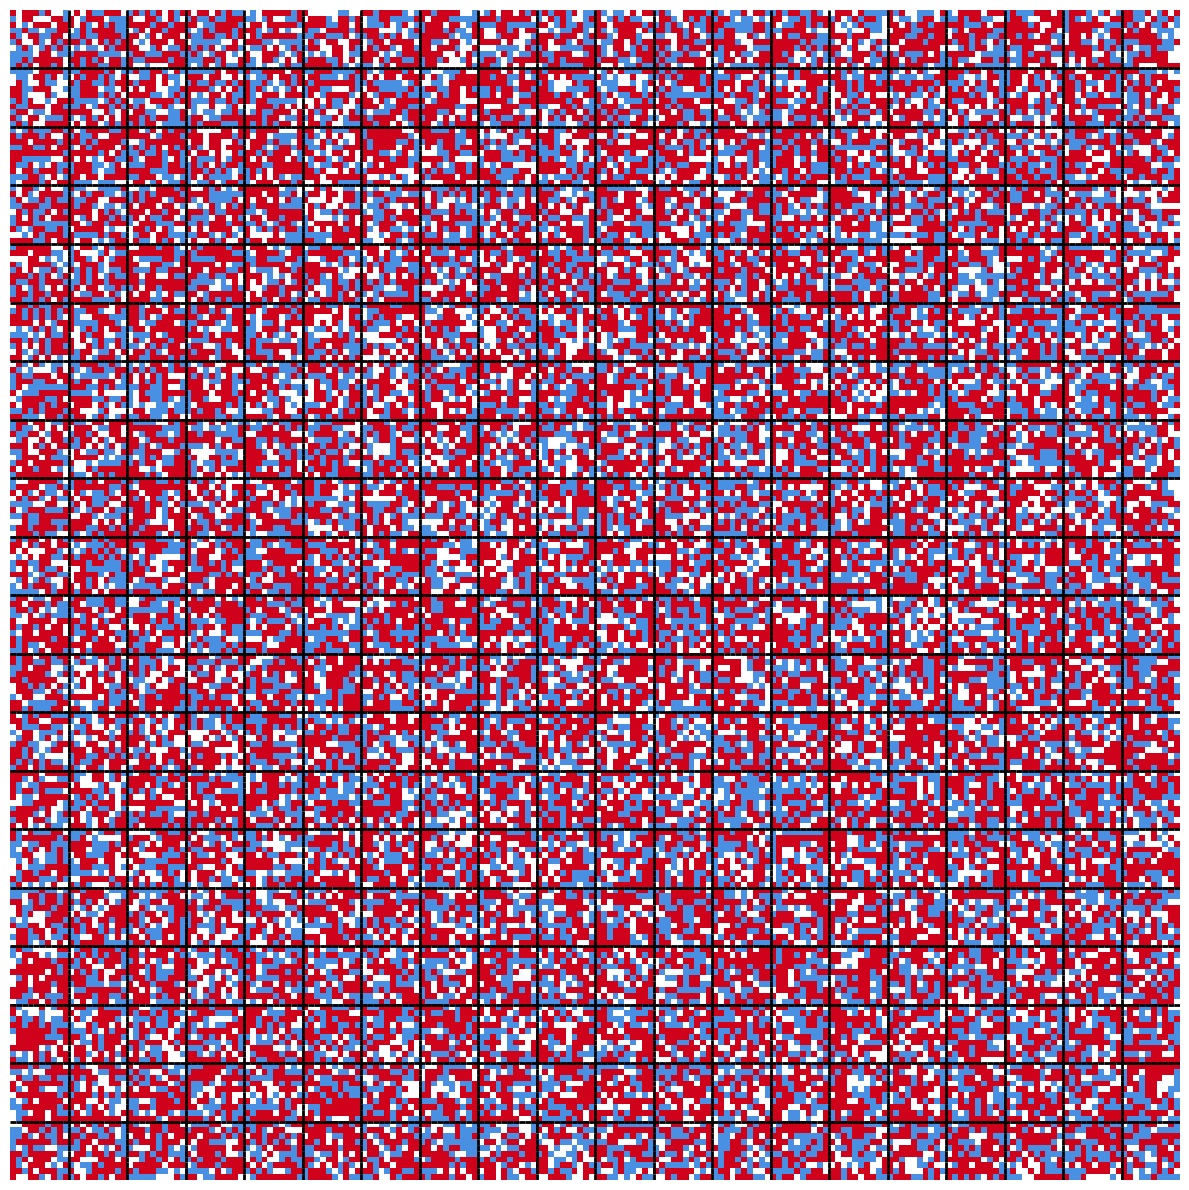

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

In [9]:
# ===== Create Neighborhood Partition =====
city_parse = seg.stripe_partition(
    (side_len, side_len),              # Grid dimensions (200×200)
    mean_size=100,                     # Average neighborhood size (100 grid locations)
    std_size=0                         # No variation in size (all neighborhoods exactly 100 grid locations)
)

# ===== Visualize Initial State =====
seg.plot_city_with_boundaries(
    dats[0][0],                        # First snapshot of first simulation (e.g., 60% red)
    city_parse                         # Neighborhood boundaries to overlay
)

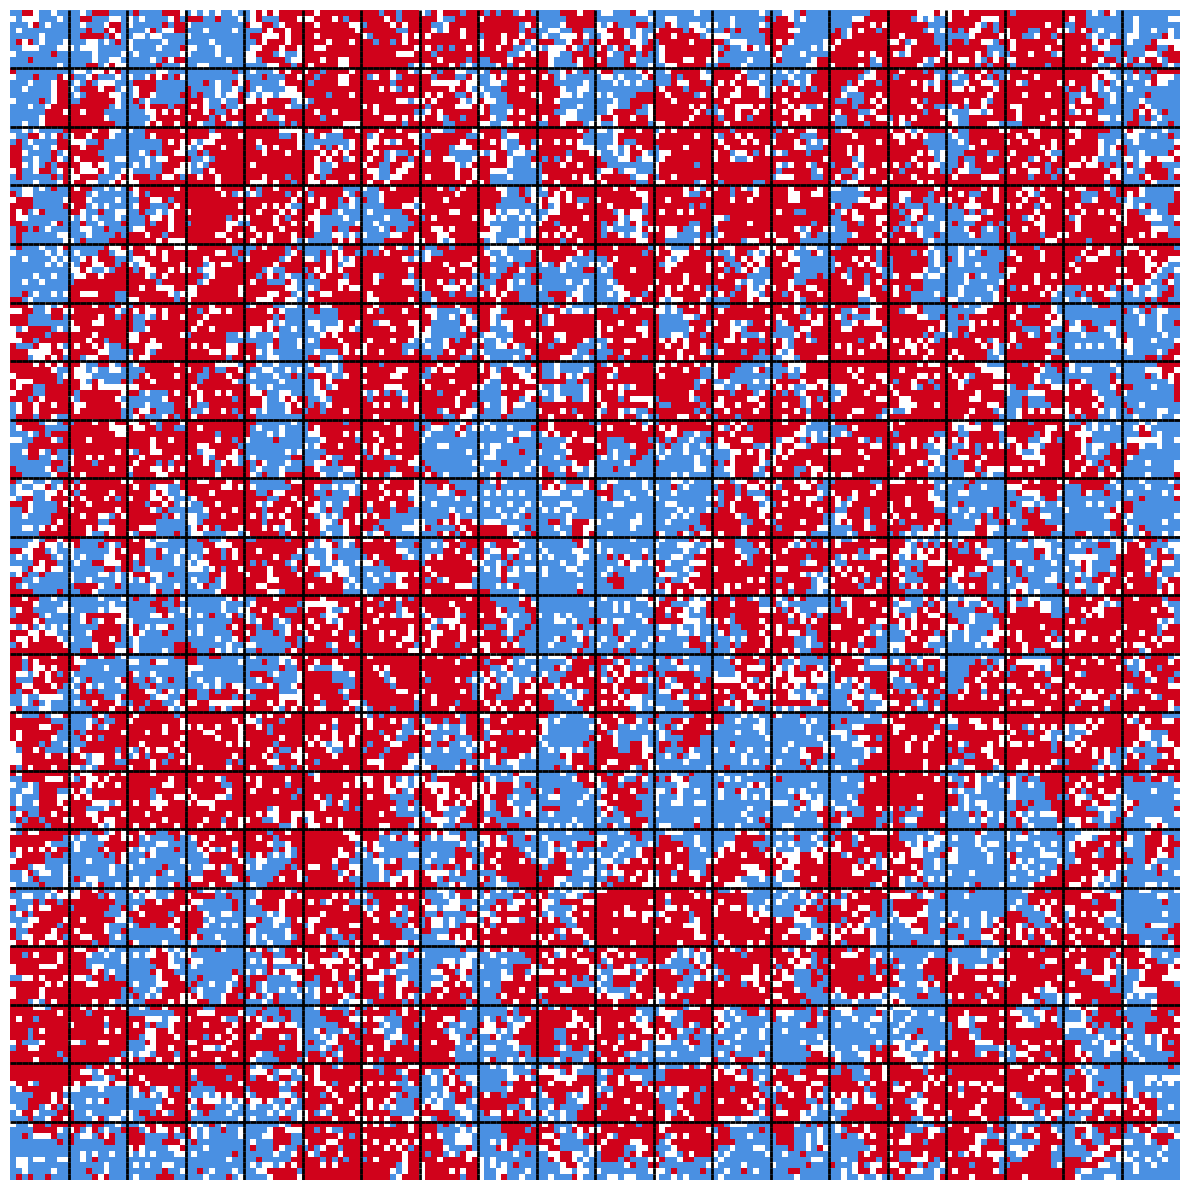

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

In [ ]:
# Plot evolved state with neighborhood boundaries
seg.plot_city_with_boundaries(dats[0][50], city_parse)  # 50th snapshot

Red 60%: μ=0.5191, σ=0.0133 (snapshots 200+)
Red 65%: μ=0.5006, σ=0.0129 (snapshots 200+)
Red 70%: μ=0.4795, σ=0.0135 (snapshots 200+)
Red 75%: μ=0.4347, σ=0.0159 (snapshots 200+)
Red 80%: μ=0.3794, σ=0.0130 (snapshots 200+)


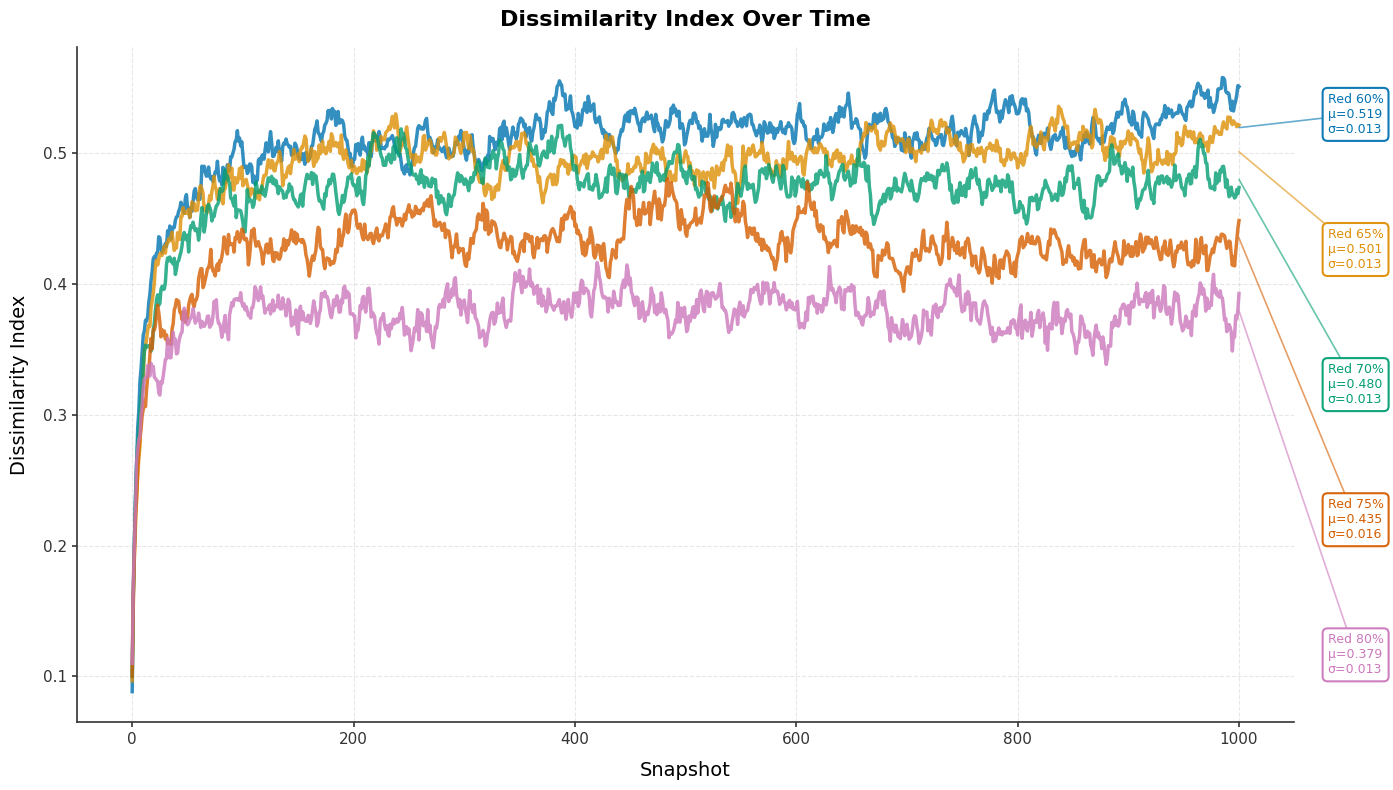

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Dissimilarity Index Over Time'}, xlabel='Snapshot', ylabel='Dissimilarity Index'>)

In [15]:
seg.plot_segregation_dynamics(
    dats,                              # Simulation data: all saved grid states
    city_parse,                        # How neighborhoods are defined
    metric='D',                        # Which segregation index to plot (Dissimilarity)
    use_adjusted=False,                # Use raw index (not composition-corrected)
    use_snapshots_after=200,           # Skip first 200 snapshots when computing statistics
    labels=[f"Red {int(val)}%" for val in 100*df['label']]  # Format as "Red 60%", "Red 65%", etc.
)

Red 60%: μ=0.4421, σ=0.0166 (snapshots 200+)
Red 65%: μ=0.4424, σ=0.0134 (snapshots 200+)
Red 70%: μ=0.4425, σ=0.0134 (snapshots 200+)
Red 75%: μ=0.4347, σ=0.0159 (snapshots 200+)
Red 80%: μ=0.4216, σ=0.0154 (snapshots 200+)


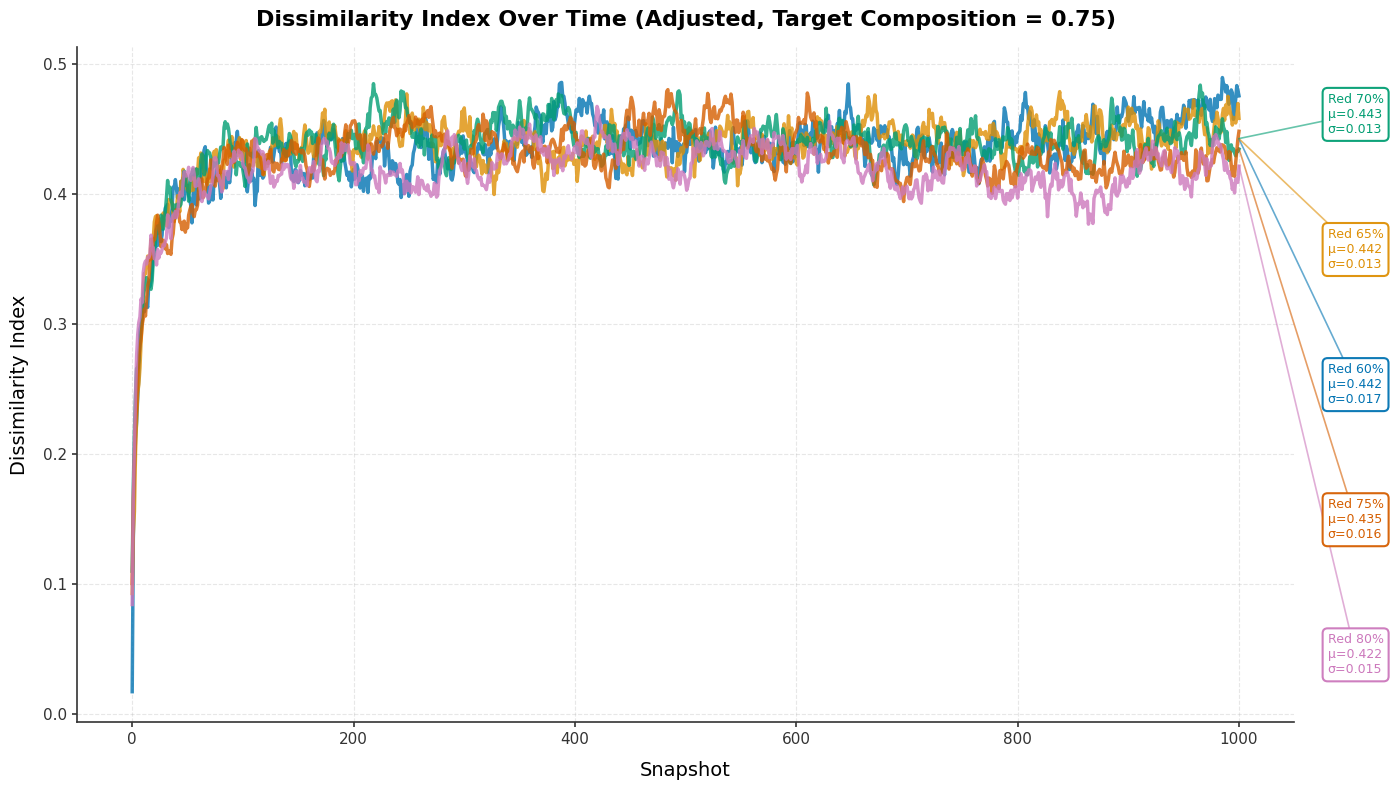

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Dissimilarity Index Over Time (Adjusted, Target Composition = 0.75)'}, xlabel='Snapshot', ylabel='Dissimilarity Index'>)

In [ ]:
seg.plot_segregation_dynamics(
    dats,                              # Simulation data: all saved grid states
    city_parse,                        # How neighborhoods are defined
    metric='D',                        # Which segregation index to plot (Dissimilarity)
    use_adjusted=True,                 # Use composition-corrected index
    target_composition=0.75,            # Adjust all indices to 80% composition for fair comparison
    use_snapshots_after=200,           # Skip first 200 snapshots when computing statistics
    labels=[f"Red {int(val)}%" for val in 100*df['label']]  # Format as "Red 60%", "Red 65%", etc.
)

In [44]:
neighborhood_data = {}                 # Dictionary to store neighborhood counts for each simulation

for i in np.arange(len(df)):           # Loop through each simulation run
    neighborhood_data[
        str(int(np.round(100*(df['label'].iloc[i]))))  # Key: label as percentage string ("60", "65", "70", etc.)
    ] = np.array([
        seg.summarize_neighborhoods(dat, city_parse[1])  # Count red/blue agents in each neighborhood
        for dat in dats[i][200:]        # Use snapshots from index 200 onwards (skip equilibration)
    ])

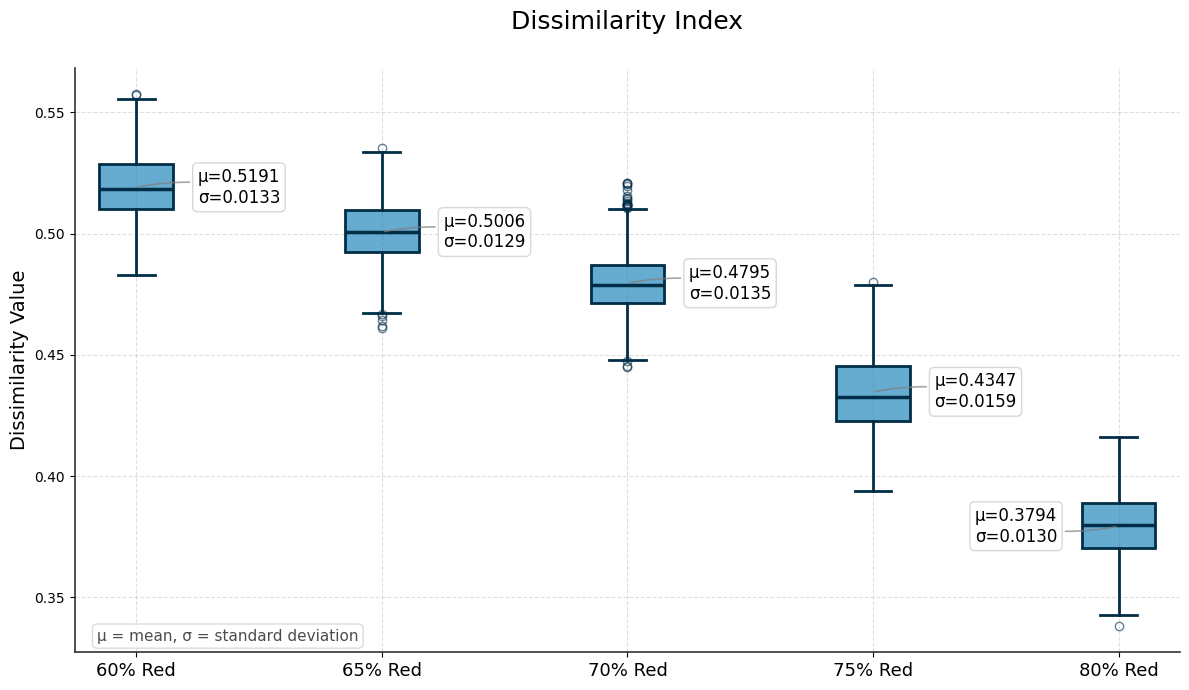

<Axes: title={'center': 'Dissimilarity Index'}, ylabel='Dissimilarity Value'>

In [ ]:
seg.plot_metric_comparison(
    neighborhood_data,              # Dictionary of neighborhood counts from different simulations
    'D',                            # Segregation metric to compare (Dissimilarity index)
    )

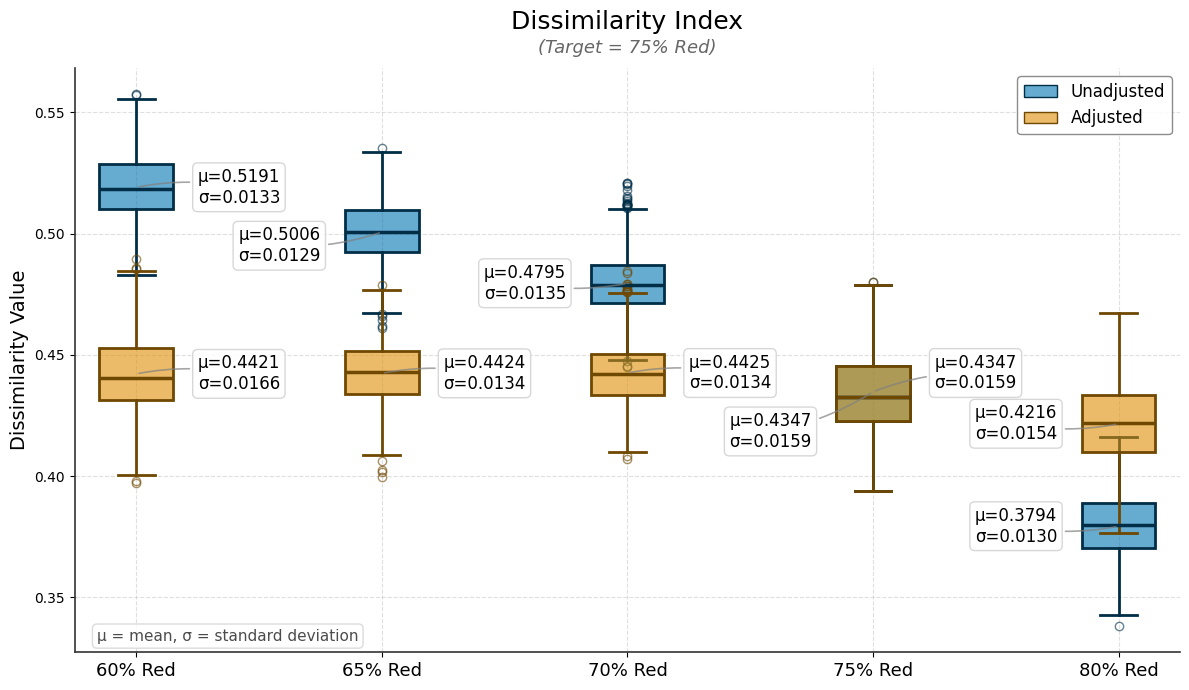

<Axes: title={'center': 'Dissimilarity Index'}, ylabel='Dissimilarity Value'>

In [ ]:
target_composition = 0.75             # Set target composition to (in this case 75% red)

seg.plot_metric_comparison(
    neighborhood_data,                # Dictionary of neighborhood counts from different simulations
    'D',                              # Segregation metric to compare (Dissimilarity index)
    show_adjusted=True,               # Show both raw and composition-corrected indices
    target_composition=target_composition,  # Adjust all indices to 75% composition
    overlay_adjusted=True             # Overlay adjusted boxes on top of unadjusted (same position)
                                      # False would show them side-by-side
)

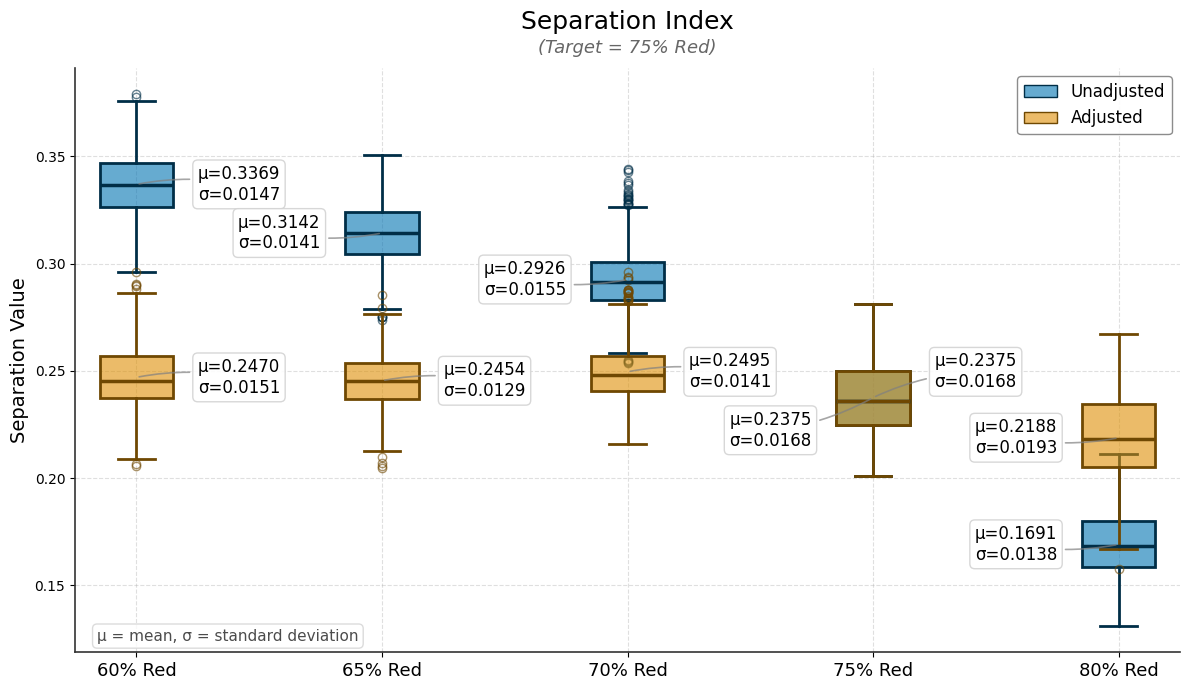

<Axes: title={'center': 'Separation Index'}, ylabel='Separation Value'>

In [ ]:
target_composition = 0.75             # Set target composition to (in this case 75% red)

seg.plot_metric_comparison(
    neighborhood_data,                # Dictionary of neighborhood counts from different simulations
    'S',                              # Segregation metric to compare (Dissimilarity index)
    show_adjusted=True,               # Show both raw and composition-corrected indices
    target_composition=target_composition,  # Adjust all indices to 75% composition
    overlay_adjusted=True             # Overlay adjusted boxes on top of unadjusted (same position)
                                      # False would show them side-by-side
)

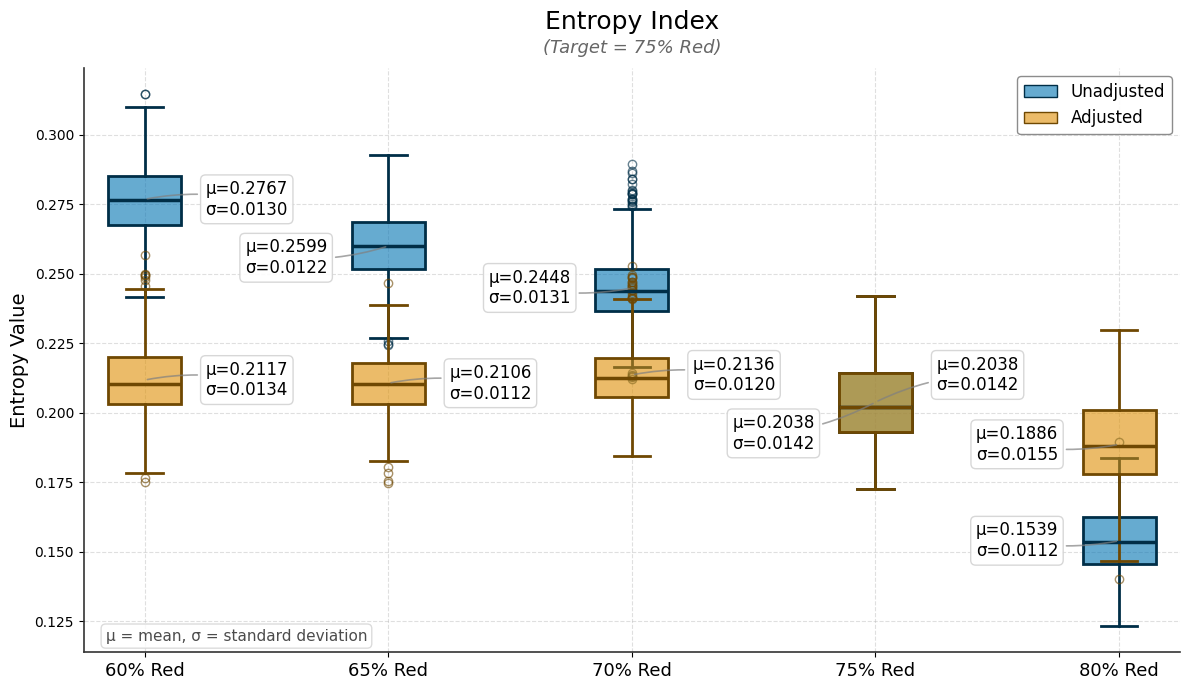

<Axes: title={'center': 'Entropy Index'}, ylabel='Entropy Value'>

In [ ]:
target_composition = 0.75             # Set target composition to (in this case 75% red)

seg.plot_metric_comparison(
    neighborhood_data,                # Dictionary of neighborhood counts from different simulations
    'Ent',                              # Segregation metric to compare (Dissimilarity index)
    show_adjusted=True,               # Show both raw and composition-corrected indices
    target_composition=target_composition,  # Adjust all indices to 75% composition
    overlay_adjusted=True             # Overlay adjusted boxes on top of unadjusted (same position)
                                      # False would show them side-by-side
)

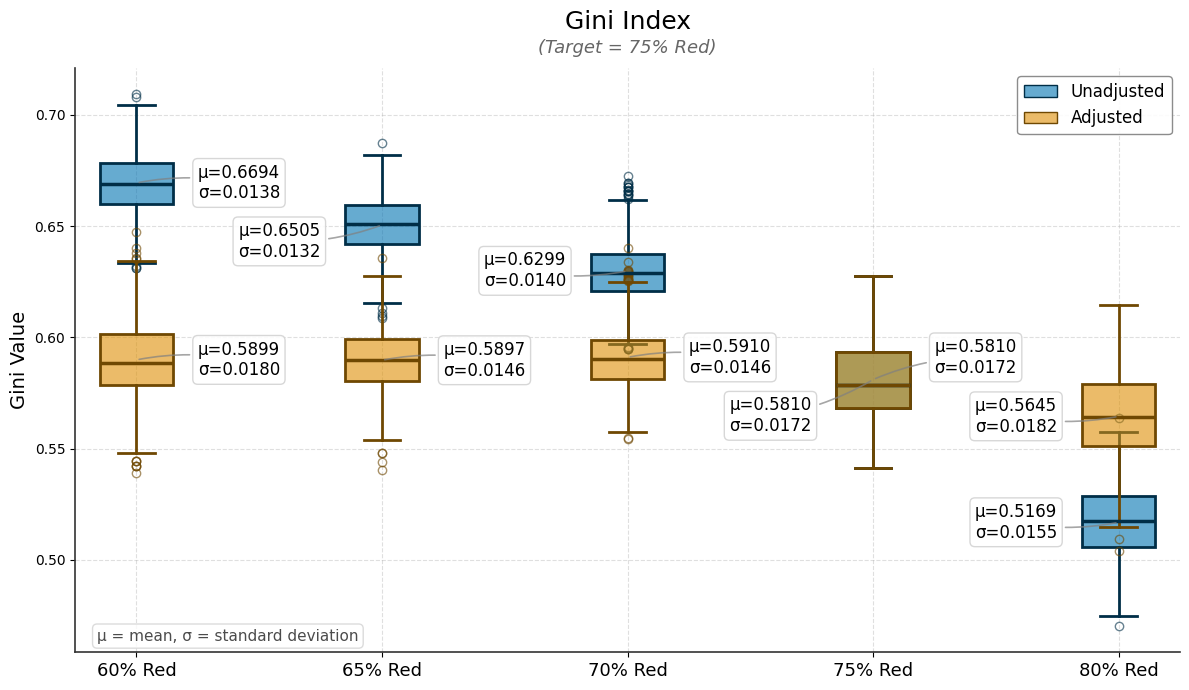

<Axes: title={'center': 'Gini Index'}, ylabel='Gini Value'>

In [ ]:
target_composition = 0.75             # Set target composition to (in this case 75% red)

seg.plot_metric_comparison(
    neighborhood_data,                # Dictionary of neighborhood counts from different simulations
    'G',                              # Segregation metric to compare (Dissimilarity index)
    show_adjusted=True,               # Show both raw and composition-corrected indices
    target_composition=target_composition,  # Adjust all indices to 75% composition
    overlay_adjusted=True             # Overlay adjusted boxes on top of unadjusted (same position)
                                      # False would show them side-by-side
)